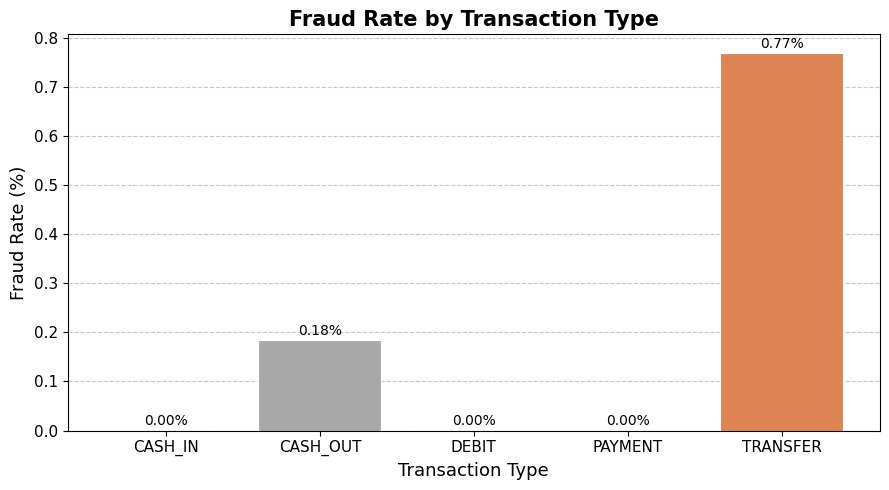

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/PS_20174392719_1491204439457_log 2.csv', on_bad_lines='skip')

fraud_rate = df.groupby('type')['isFraud'].mean() * 100

colors = ['#DD8452' if t == 'TRANSFER' else '#A8A8A8' for t in fraud_rate.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(fraud_rate.index, fraud_rate.values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_xlabel('Transaction Type', fontsize=13)
ax.set_ylabel('Fraud Rate (%)', fontsize=13)
ax.set_title('Fraud Rate by Transaction Type', fontsize=15, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)

for bar, val in zip(bars, fraud_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/chart.png', dpi=150, bbox_inches='tight')
plt.show()